In [1]:
import pandas as pd
import numpy as np
import datetime
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.utils.tensorboard import SummaryWriter
from tqdm.notebook import tqdm
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score, accuracy_score




In [2]:
class ContinuousValueEmbedding(nn.Module):
    """
    Continuous Value Embedding for time and values.
    """
    def __init__(self, input_dim, embed_dim, activation='tanh'):
        super().__init__()
        self.hidden_dim = int(embed_dim ** 0.5)
        self.lin1 = nn.Linear(input_dim, self.hidden_dim)
        self.lin2 = nn.Linear(self.hidden_dim, embed_dim)
        self.activation = torch.tanh if activation == 'tanh' else nn.ReLU()

    def forward(self, x):
        x = self.lin1(x)
        x = self.activation(x)
        return self.lin2(x)

class TransformerBlock(nn.Module):
    """
    A single Transformer block for the model.
    """
    def __init__(self, embed_dim, num_heads, ff_dim, dropout):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.feedforward = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim)
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, padding_mask):
        attn_mask = ~padding_mask.bool()
        attn_output, _ = self.attention(x, x, x, key_padding_mask=attn_mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feedforward(x)
        return self.norm2(x + self.dropout(ff_output))

class FusionAttention(nn.Module):
    """
    Fusion Attention to aggregate contextual embeddings.
    """
    def __init__(self, embed_dim):
        super().__init__()
        self.W = nn.Parameter(torch.empty(embed_dim, embed_dim))
        self.b = nn.Parameter(torch.zeros(embed_dim))
        self.u = nn.Parameter(torch.empty(embed_dim, 1))
        nn.init.xavier_uniform_(self.W)
        nn.init.xavier_uniform_(self.u)

    def forward(self, x, mask):
        att = torch.tanh(torch.matmul(x, self.W) + self.b)
        scores = torch.matmul(att, self.u).squeeze(-1)
        scores = scores + (1 - mask) * torch.finfo(scores.dtype).min
        weights = F.softmax(scores, dim=-1)
        return weights

class CLSHead(nn.Module):
    """
    Head for CLS token pooling.
    """
    def __init__(self, embed_dim):
        super().__init__()
        self.dense = nn.Linear(embed_dim, embed_dim)
        self.activation = nn.Tanh()

    def forward(self, x):
        x = self.dense(x)
        return self.activation(x)
    
class FrcstHead(nn.Module):
    """
    Head for masked value forecasting
    """
    def __init__(self, embed_dim, output_dim):
        super().__init__()
        self.lin1 = nn.Linear(embed_dim, embed_dim)
        self.activation = nn.ReLU()
        self.lin2 = nn.Linear(embed_dim, output_dim)

    def forward(self, x):
        x = self.lin1(x)
        x = self.activation(x)
        x = self.lin2(x)
        return x


class STraTSModel(nn.Module):
    """
    Main model definition for the STraTS task, 
    now using dataset-provided mask for pretrain.
    """
    def __init__(self, num_features, embed_dim, num_heads, num_blocks, ff_dim,
                 dropout, activation='tanh', final_emb_type='balanced', fusion_emb_weight=0.5):
        super().__init__()

        # ------------------------------
        # (1) Transformer + Embeddings
        # ------------------------------
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_blocks)
        ])
        self.fusion_attention = FusionAttention(embed_dim)
        self.time_embed = ContinuousValueEmbedding(input_dim=1, embed_dim=embed_dim, activation='relu')
        self.value_embed = ContinuousValueEmbedding(input_dim=1, embed_dim=embed_dim, activation=activation)
        self.feature_embed = nn.Embedding(num_features + 1, embed_dim)

        # pretrain 시계열 예측 head
        self.forecast_head = FrcstHead(embed_dim, num_features+1)

        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(embed_dim)

        # ------------------------------
        # (2) Downstream heads
        # ------------------------------
        self.linear_saps = nn.Linear(embed_dim, 1)
        self.linear_sofa = nn.Linear(embed_dim, 1)
        self.linear_death = nn.Linear(embed_dim, 1)

        # ------------------------------
        # (3) CLS token & heads
        # ------------------------------
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.xavier_uniform_(self.cls_token)
        self.cls_head = CLSHead(embed_dim)
        self.similarity = nn.CosineSimilarity(dim=-1)

        # ------------------------------
        # (4) 설정
        # ------------------------------
        self.final_emb_type = final_emb_type
        self.fusion_emb_weight = fusion_emb_weight

    def forward(self, 
                times, varis, values, 
                padding_mask, 
                pretrain=False, 
                pretrain_mask=None, 
                outcomes=None,
                freeze_pretrained=False):
        """
        - pretrain=True  => 마스킹 기반 시계열 예측 (forecast) 수행
        - pretrain_mask : (batch_size, seq_len) - bool (True=mask)
        - freeze_pretrained=True => pretrain 모듈 파라미터 고정 (Transformer, embeddings, etc)
        - outcomes=(batch_size, 4) => [hadm_id, saps, sofa, death] (downstream)
        """

        # -----------------------------------------
        # 1) Freeze if requested (downstream only)
        # -----------------------------------------
        if freeze_pretrained and not pretrain:
            for param in self.transformer_blocks.parameters():
                param.requires_grad = False
            for param in self.fusion_attention.parameters():
                param.requires_grad = False
            for param in self.time_embed.parameters():
                param.requires_grad = False
            for param in self.value_embed.parameters():
                param.requires_grad = False
            for param in self.feature_embed.parameters():
                param.requires_grad = False
            for param in self.forecast_head.parameters():
                param.requires_grad = False

        # -----------------------------------------
        # 2) Embeddings
        # -----------------------------------------
        bsz, seq_len = values.size()
        cls_tokens = self.cls_token.expand(bsz, -1, -1)  # [bsz, 1, embed_dim]

        time_emb = self.time_embed(times.unsqueeze(-1))
        value_emb = self.value_embed(values.unsqueeze(-1))
        feature_emb = self.feature_embed(varis)

        # -----------------------------------------
        # 3) Pretrain => use pretrain_mask
        #    pretrain_mask[i,j] = True => 그 시점(mask)
        # -----------------------------------------
        if pretrain:
            # mask=1 => "keep" in old logic, so we invert from dataset's bool 
            # dataset says True=> mask => zero out
            # in old code: mask=1 => unmasked => multiply => original
            # => we define: net_mask = 1 - pretrain_mask.float()
            # so if pretrain_mask=1 => net_mask=0 => zero out
            net_mask = 1 - pretrain_mask.float()  # shape: [bsz, seq_len]
            masked_value_emb = value_emb * net_mask.unsqueeze(-1)
            triplet_emb = time_emb + masked_value_emb + feature_emb
        else:
            triplet_emb = time_emb + value_emb + feature_emb

        triplet_emb = self.dropout(triplet_emb)
        # CLS concat
        triplet_emb = torch.cat([cls_tokens, triplet_emb], dim=1)

        cls_pad = torch.ones((bsz, 1), device=padding_mask.device)
        att_padding_mask = torch.cat([cls_pad, padding_mask], dim=1)
        fus_padding_mask = torch.cat([torch.zeros_like(cls_pad), padding_mask], dim=1)

        # -----------------------------------------
        # 4) Transformer Blocks
        # -----------------------------------------
        for block in self.transformer_blocks:
            triplet_emb = block(triplet_emb, att_padding_mask)

        # CLS pooling
        cls_emb = self.cls_head(triplet_emb[:, 0, :])

        # -----------------------------------------
        # 5) Final Embedding (fusion vs cls etc.)
        # -----------------------------------------
        if self.final_emb_type == 'balanced':
            fusion_weights = self.fusion_attention(triplet_emb, fus_padding_mask)
            fusion_emb = (triplet_emb * fusion_weights.unsqueeze(-1)).sum(dim=1)
            fusion_emb = self.layer_norm(fusion_emb)
            final_emb = self.fusion_emb_weight * fusion_emb + (1 - self.fusion_emb_weight) * cls_emb
        elif self.final_emb_type == 'cls':
            final_emb = cls_emb
        elif self.final_emb_type == 'fusion':
            fusion_weights = self.fusion_attention(triplet_emb, fus_padding_mask)
            fusion_emb = (triplet_emb * fusion_weights.unsqueeze(-1)).sum(dim=1)
            fusion_emb = self.layer_norm(fusion_emb)
            final_emb = fusion_emb
        else:
            print(f'Invalid final_emb_type of "{self.final_emb_type}", default to balanced.')
            final_emb = cls_emb

        # -----------------------------------------
        # 6) Pretrain => Forecast Head
        # -----------------------------------------
        if pretrain:
            # [bsz, seq_len+1, embed_dim]
            triplet_emb_seq = triplet_emb[:, 1:, :]  # CLS 제외
            seq_emb = (triplet_emb_seq + final_emb.unsqueeze(1)) / 2

            forecast = self.forecast_head(seq_emb)    # [bsz, seq_len, num_features+1]
            gather_input = varis.unsqueeze(-1)        # [bsz, seq_len, 1]
            forecast_selected = torch.gather(forecast, 2, gather_input)  # => [bsz, seq_len, 1]
            forecast_selected = forecast_selected.squeeze(-1)            # => [bsz, seq_len]

            # 모델 내부적 "mask"는 net_mask=1 => unmasked, net_mask=0 => masked
            # loss는 "masked 지점"만 계산 => (1 - net_mask) = pretrain_mask
            masked_loss = pretrain_mask.float() * padding_mask  # [bsz, seq_len]
            pred_masked = forecast_selected * masked_loss
            gt_masked = values * masked_loss

            diff = pred_masked - gt_masked
            sq_diff = diff ** 2
            sum_sq_diff = sq_diff.sum()
            sum_masked_loss = masked_loss.sum()

            if sum_masked_loss == 0:
                mse_loss = torch.tensor(0.0, device=values.device)
            else:
                mse_loss = sum_sq_diff / sum_masked_loss

            return {
                'forecast': forecast_selected,
                'values': values,
                'varis': varis,
                'times': times,
                'mask': pretrain_mask,  # (bool)
                'loss': mse_loss
            }

        # -----------------------------------------
        # 7) Downstream => SAPS/SOFA/Death
        # -----------------------------------------
        pred_saps  = self.linear_saps(final_emb)       # [bsz, 1]
        pred_sofa  = self.linear_sofa(final_emb)       # [bsz, 1]
        pred_death = torch.sigmoid(self.linear_death(final_emb))

        if outcomes is not None:
            # outcomes=(bsz, 4) => [hadm_id, saps_label, sofa_label, death_label]
            hadm_id     = outcomes[:, 0]
            saps_label  = outcomes[:, 1]
            sofa_label  = outcomes[:, 2]
            death_label = outcomes[:, 3]

            # 예시로 death만 loss 계산
            loss_saps  = F.mse_loss(pred_saps.squeeze(-1), saps_label)
            loss_sofa  = F.mse_loss(pred_sofa.squeeze(-1), sofa_label)
            loss_death = F.binary_cross_entropy(pred_death.squeeze(-1), death_label)
            total_loss = loss_death  # 필요 시 세 개 더하거나 가중치 적용

            return {
                'hadm_id': hadm_id,
                'pred_saps':  pred_saps,
                'pred_sofa':  pred_sofa,
                'pred_death': pred_death,
                'saps': saps_label,
                'sofa': sofa_label,
                'death': death_label,
                'loss': total_loss,
                'loss_saps': loss_saps,
                'loss_sofa': loss_sofa,
                'loss_death': loss_death
            }
        else:
            # Inference only
            return {
                'pred_saps':  pred_saps,
                'pred_sofa':  pred_sofa,
                'pred_death': pred_death
            }


In [3]:
def pretrain_model(model, train_loader, valid_loader, epochs, optimizer, device,
                    patience=7, model_save_path='best_pretrained_dmask_model.pt'):
    writer = SummaryWriter()
    model.to(device)
    best_valid_loss = float('inf')
    early_stop_counter = 0
    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0

        for batch in tqdm(train_loader, desc=f"[Pretrain] Epoch [{epoch+1}/{epochs}] - Training", leave=False):
            # 예상되는 batch 구조: (times, varis, values, saps, sofa, death, padding_mask)
            # 하지만 pretrain에서는 saps/sofa/death가 필요하지 않으므로 '_'로 받거나 무시.
            hadm_id, times, varis, values, _, _, _, mask_t, padding_mask = [x.to(device) for x in batch]
            
            optimizer.zero_grad()
            outputs = model(times, varis, values, 
                            padding_mask=padding_mask, 
                            pretrain=True,
                            pretrain_mask = mask_t)  # <-- pretrain=True
            loss = outputs['loss']

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # Validation phase
        valid_loss = 0
        model.eval()
        with torch.no_grad():
            for batch in tqdm(valid_loader, desc=f"[Pretrain] Epoch [{epoch+1}/{epochs}] - Validation", leave=False):
                hadm_id, times, varis, values, _, _, _, mask_t, padding_mask = [x.to(device) for x in batch]
                outputs = model(times, varis, values, 
                                padding_mask=padding_mask, 
                                pretrain=True,
                                pretrain_mask = mask_t)
                valid_loss += outputs['loss'].item()
        valid_loss /= len(valid_loader)
        valid_losses.append(valid_loss)

        print(f"[Pretrain] Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Valid Loss = {valid_loss:.4f}")

        # Early stopping
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), model_save_path)
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print("Early stopping triggered (pretrain).")
            break

    writer.close()
    epochs_range = range(1, len(train_losses) + 1)
    plt.figure(figsize=(8, 6))
    plt.plot(epochs_range, train_losses, label='Train Loss')
    plt.plot(epochs_range, valid_losses, label='Valid Loss')
    plt.title('Pretraining Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

def train_model(model, train_loader, valid_loader, epochs, optimizer, device,
                 patience=7, freeze=False, model_save_path='best_downstream_dmask_model.pt'):
    writer = SummaryWriter()
    model.to(device)
    best_valid_loss = float('inf')
    early_stop_counter = 0

    train_losses = []
    train_saps_losses = []
    train_sofa_losses = []
    train_death_losses = []

    valid_losses = []
    valid_saps_losses = []
    valid_sofa_losses = []
    valid_death_losses = []

    # AUROC / AUPRC 기록용
    valid_aurocs = []
    valid_auprcs = []

    for epoch in range(epochs):
        # ===================================================
        # (1) Training phase
        # ===================================================
        model.train()
        train_loss = 0
        train_saps_loss = 0
        train_sofa_loss = 0
        train_death_loss = 0

        for batch in tqdm(train_loader, desc=f"[Downstream] Epoch [{epoch+1}/{epochs}] - Training", leave=False):
            hadm_id, times, varis, values, saps, sofa, death, _, padding_mask = [x.to(device) for x in batch]
            
            # outcomes: shape (batch_size, 4) => [hadm_id, saps_label, sofa_label, death_label]
            outcomes = torch.stack([hadm_id, saps, sofa, death], dim=1)

            optimizer.zero_grad()
            # pretrain=False, 전달된 outcomes로 loss 계산
            outputs = model(times, varis, values, 
                            padding_mask=padding_mask, 
                            pretrain=False,
                            freeze_pretrained = freeze, 
                            outcomes=outcomes)

            loss = outputs['loss']
            loss_saps  = outputs['loss_saps']
            loss_sofa  = outputs['loss_sofa']
            loss_death = outputs['loss_death']

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_saps_loss += loss_saps.item()
            train_sofa_loss += loss_sofa.item()
            train_death_loss += loss_death.item()

        # epoch 단위 평균
        train_loss       /= len(train_loader)
        train_saps_loss  /= len(train_loader)
        train_sofa_loss  /= len(train_loader)
        train_death_loss /= len(train_loader)

        train_losses.append(train_loss)
        train_saps_losses.append(train_saps_loss)
        train_sofa_losses.append(train_sofa_loss)
        train_death_losses.append(train_death_loss)

        # ===================================================
        # (2) Validation phase
        # ===================================================
        valid_loss = 0
        valid_saps_loss = 0
        valid_sofa_loss = 0
        valid_death_loss = 0

        # -----------------------------
        # (a) AUROC/AUPRC 계산 위해 전체 배치 예측/라벨 누적
        # -----------------------------
        death_preds_all = []
        death_labels_all = []

        model.eval()
        with torch.no_grad():
            for batch in tqdm(valid_loader, desc=f"[Downstream] Epoch [{epoch+1}/{epochs}] - Validation", leave=False):
                hadm_id, times, varis, values, saps, sofa, death, _, padding_mask = [x.to(device) for x in batch]
                outcomes = torch.stack([hadm_id, saps, sofa, death], dim=1)

                outputs = model(times, varis, values, 
                                padding_mask=padding_mask, 
                                pretrain=False,
                                freeze_pretrained=freeze, 
                                outcomes=outcomes)

                loss       = outputs['loss']
                loss_saps  = outputs['loss_saps']
                loss_sofa  = outputs['loss_sofa']
                loss_death = outputs['loss_death']

                valid_loss       += loss.item()
                valid_saps_loss  += loss_saps.item()
                valid_sofa_loss  += loss_sofa.item()
                valid_death_loss += loss_death.item()

                # -----------------------
                # (b) death pred & label
                # -----------------------
                # pred_death: (batch_size, 1) => sigmoid output
                # death_label: (batch_size,)
                pred_death  = outputs['pred_death'].squeeze(-1)  # shape: [bsz]
                death_label = outputs['death']  # shape: [bsz]

                # cpu로 옮겨 numpy 변환
                pred_death_np  = pred_death.detach().cpu().numpy()
                death_label_np = death_label.detach().cpu().numpy()

                death_preds_all.append(pred_death_np)
                death_labels_all.append(death_label_np)

        # (c) epoch 단위 평균 Loss
        valid_loss       /= len(valid_loader)
        valid_saps_loss  /= len(valid_loader)
        valid_sofa_loss  /= len(valid_loader)
        valid_death_loss /= len(valid_loader)

        valid_losses.append(valid_loss)
        valid_saps_losses.append(valid_saps_loss)
        valid_sofa_losses.append(valid_sofa_loss)
        valid_death_losses.append(valid_death_loss)

        # -----------------------
        # (d) AUROC / AUPRC 계산
        # -----------------------
        # stack 전체 death 예측/라벨 => shape (N,)
        death_preds_all = np.concatenate(death_preds_all, axis=0)
        death_labels_all = np.concatenate(death_labels_all, axis=0)

        auroc = roc_auc_score(death_labels_all, death_preds_all)
        auprc = average_precision_score(death_labels_all, death_preds_all)

        valid_aurocs.append(auroc)
        valid_auprcs.append(auprc)

        print(f"[Epoch {epoch+1}] Train Loss={train_loss:.4f}, Valid Loss={valid_loss:.4f}, "
              f"Valid AUROC={auroc:.4f}, AUPRC={auprc:.4f}")

        # (e) Early stopping
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            if freeze:
                torch.save(model.state_dict(), "best_frozen_downstream_dmask_model_relutime.pt")
            else:
                torch.save(model.state_dict(), model_save_path)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
        if early_stop_counter >= patience:
            print("Early stopping triggered (downstream).")
            break

    writer.close()

    # (3) 에폭별 결과 시각화/데이터프레임 생성
    epochs_range = range(1, len(train_losses) + 1)

    plt.figure(figsize=(8, 6))
    plt.plot(epochs_range, train_losses, label='Train Loss')
    plt.plot(epochs_range, valid_losses, label='Valid Loss')
    plt.title('Downstream Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # 추가: AUROC, AUPRC 시각화(옵션)
    plt.figure()
    plt.plot(epochs_range, valid_aurocs, label='Valid AUROC')
    plt.plot(epochs_range, valid_auprcs, label='Valid AUPRC')
    plt.title('Death Prediction Metrics')
    plt.xlabel('Epoch')
    plt.ylabel('Metric')
    plt.legend()
    plt.show()

    # (4) DataFrame
    # zip(*...)로 행=epoch, 열=각 metric
    data = list(zip(train_losses, train_saps_losses, train_sofa_losses, train_death_losses,
                    valid_losses, valid_saps_losses, valid_sofa_losses, valid_death_losses,
                    valid_aurocs, valid_auprcs))
    columns = ['Train loss', 'Train SAPS', 'Train SOFA', 'Train DEATH',
               'Valid loss', 'Valid SAPS', 'Valid SOFA', 'Valid DEATH',
               'Valid AUROC', 'Valid AUPRC']
    loss_df = pd.DataFrame(data=data, columns=columns)

    return loss_df

In [23]:
def validate_model(model, valid_loader, device):
    model.eval()
    results = []


    with torch.no_grad():
        for batch in valid_loader:
            hadm_id, times, varis, values, _, _, _, mask_t, padding_mask = [x.to(device) for x in batch]

            # Forward pass
            outputs = model(times, varis, values, padding_mask, pretrain=True, pretrain_mask = mask_t)

            # Gather outputs
            for i in range(times.size(0)):  # Loop through the batch
                result = pd.DataFrame({
                    'hadm_id': hadm_id[i].cpu().numpy().tolist(),
                    'Time': times[i].cpu().numpy().tolist(),
                    'Variable': varis[i].cpu().numpy().tolist(),
                    'True Value': values[i].cpu().numpy().tolist(),
                    'Predicted Value': outputs['forecast'][i].cpu().numpy().tolist(),
                    'Mask': outputs['mask'][i].cpu().numpy().tolist()
                })
                results.append(result)

    # Convert results to a DataFrame
    df = pd.concat(results)
    return df

def validate_model_downstream(model, valid_loader, device):
    results = []
    model.eval()
    with torch.no_grad():
        for batch in valid_loader:
            hadm_id, times, varis, values, saps, sofa, death, _, padding_mask = [x.to(device) for x in batch]
            outcomes = torch.stack([hadm_id, saps, sofa, death], dim=1)

            outputs = model(times, varis, values, 
                            padding_mask=padding_mask, 
                            pretrain=False, 
                            outcomes=outcomes)

            result = pd.DataFrame({
                'hadm_id': outputs['hadm_id'].cpu().numpy().tolist(),
                'pred_saps': outputs['pred_saps'].cpu().numpy().tolist(),
                'pred_sofa': outputs['pred_sofa'].cpu().numpy().tolist(),
                'pred_death': outputs['pred_death'].cpu().numpy().tolist(),
                'saps': outputs['saps_label'].cpu().numpy().tolist(),
                'sofa': outputs['sofa_label'].cpu().numpy().tolist(),
                'death': outputs['death_label'].cpu().numpy().tolist(),                       
            })
            results.append(result)
    df = pd.concat(results)
    return df

In [5]:
def evaluate_model(model, test_loader, device):
    """
    Test set에 대해 모델 추론 후, 다양한 분류 지표를 계산하는 함수.
    
    모델은 pred_death(= 사망 확률, 0~1)를 반환한다고 가정.
    실제 라벨(0/1)은 death로 가정.
    
    Parameters
    ----------
    model : nn.Module
        학습이 완료된 PyTorch 모델
    test_loader : DataLoader
        테스트 데이터셋 로더 (배치별로 hadm_id, times, varis, values, saps, sofa, death, padding_mask 등 반환)
    device : torch.device
        CUDA 또는 CPU
    
    Returns
    -------
    metrics : dict
        {
          'AUROC': float,
          'AUPRC': float,
          'Precision': float,
          'Recall': float,
          'F1': float,
          'Accuracy': float
        }
    """

    model.eval()  # 추론 모드
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            # 배치 구조 예: hadm_id, times, varis, values, saps, sofa, death, padding_mask
            hadm_id, times, varis, values, saps, sofa, death, _, padding_mask = [x.to(device) for x in batch]

            # 모델에 전달할 outcomes (hadm_id, saps, sofa, death) - 필요 시 정의
            outcomes = torch.stack([hadm_id, saps, sofa, death], dim=1)

            # 추론
            outputs = model(times, varis, values, padding_mask=padding_mask, 
                            pretrain=False, outcomes=outcomes)

            # 모델이 반환하는 사망 확률 (배치 x 1)
            pred_death = outputs['pred_death'].squeeze(-1)  # (batch_size,)
            # 실제 라벨
            label_death = outputs['death']                  # (batch_size,)

            # CPU로 옮겨서 numpy로 변환
            all_preds.append(pred_death.detach().cpu().numpy())
            all_labels.append(label_death.detach().cpu().numpy())

    # 전체 배치를 합쳐서 (N,) 형태가 됨
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    # AUROC (roc_auc_score), AUPRC (average_precision_score)는 확률값 사용
    auroc = roc_auc_score(all_labels, all_preds)
    auprc = average_precision_score(all_labels, all_preds)

    # Precision, Recall, F1, Accuracy 등은 threshold=0.5로 이진화하여 계산
    pred_binary = (all_preds >= 0.5).astype(int)

    prec = precision_score(all_labels, pred_binary)
    rec  = recall_score(all_labels, pred_binary)
    f1   = f1_score(all_labels, pred_binary)
    acc  = accuracy_score(all_labels, pred_binary)

    metrics = {
        'AUROC': auroc,
        'AUPRC': auprc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'Accuracy': acc
    }

    return metrics

In [6]:
outcome_a = pd.read_feather('pcc2012_a_outcome.feather')
outcome_b = pd.read_feather('pcc2012_b_outcome.feather')
outcome_c = pd.read_feather('pcc2012_c_outcome.feather')
def process_outcome(outcome):
    outcome = outcome.loc[:,['RecordID', 'SAPS-I', 'SOFA', 'In-hospital_death']]
    outcome = outcome.rename(columns={'RecordID': 'hadm_id', 'In-hospital_death' : 'death'})
    outcome = outcome.loc[(outcome.loc[:,'SAPS-I']!= -1) & (outcome.loc[:,'SOFA']!= -1),:]
    unique_outcome_ids = outcome['hadm_id'].unique()
    return outcome, unique_outcome_ids
outcome_a, a_ids = process_outcome(outcome_a)
outcome_b, b_ids = process_outcome(outcome_b)
outcome_c, c_ids = process_outcome(outcome_c)

In [7]:
data_a = pd.read_feather('pcc2012_a.feather')
data_b = pd.read_feather('pcc2012_b.feather')
data_c = pd.read_feather('pcc2012_c.feather')

data = pd.concat([data_a, data_b, data_c])

data = data.rename(columns={'time' : 'offset', 'recordid' : 'hadm_id', 'parameter' : 'itemid'})

# Factorize the 'item' column and get the mapping
encoded, actual_class = pd.factorize(data['itemid'])
data.loc[:,'itemid'] = encoded.astype(int)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

data = data.dropna(subset=['value'])

item_dict = dict(zip(actual_class, range(len(actual_class))))
emb_idx = len(item_dict)

unique_hadm_ids = np.concatenate([b_ids, c_ids])

# 재현성 유지를 위해 seed를 고정하고 섞습니다.
np.random.seed(42)
np.random.shuffle(unique_hadm_ids)

# 예: 80%를 train, 나머지를 valid로 사용
train_size = int(len(unique_hadm_ids) * 0.8)
train_hadm_ids = unique_hadm_ids[:train_size]
valid_hadm_ids = unique_hadm_ids[train_size:]
test_hadm_ids = a_ids

train_df = data[data['hadm_id'].isin(train_hadm_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_hadm_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_hadm_ids)].copy().reset_index(drop=True)

outcome_bc = pd.concat([outcome_b, outcome_c])
train_outcome_df = outcome_bc[outcome_bc['hadm_id'].isin(train_hadm_ids)].copy()
valid_outcome_df = outcome_bc[outcome_bc['hadm_id'].isin(valid_hadm_ids)].copy()
test_outcome_df = outcome_a[outcome_a['hadm_id'].isin(test_hadm_ids)].copy()


scalers_dict = {}  

for item_id, group in train_df.groupby('itemid'):
    scaler = StandardScaler()
    scaled_values = scaler.fit_transform(group['value'].values.reshape(-1, 1))
    
    # group에는 스케일링한 값을 '직접' 넣어봤자 원본은 바뀌지 않음
    # 대신 group.index를 활용해 원본 DF에 반영
    train_df.loc[group.index, 'value'] = scaled_values
    
    scalers_dict[item_id] = scaler

for item_id, group in valid_df.groupby('itemid'):
    scaler = scalers_dict[item_id]  # 이미 학습된 scaler 사용
    scaled_values = scaler.transform(group['value'].values.reshape(-1, 1))
    valid_df.loc[group.index, 'value'] = scaled_values

for item_id, group in test_df.groupby('itemid'):
    scaler = scalers_dict[item_id]  # 이미 학습된 scaler 사용
    scaled_values = scaler.transform(group['value'].values.reshape(-1, 1))
    test_df.loc[group.index, 'value'] = scaled_values

In [8]:
class TimeSeriesDatasetFixedTimeMask(Dataset):
    def __init__(self, df, outcome_df, observation_window, step, mode='train',
                 mask_length=600):
        """
        mask_length: 무작위로 마스킹할 연속된 시간 구간 길이(분 단위)
        """
        self.samples = []
        self.observation_window = observation_window
        self.step = step
        self.mode = mode
        self.mask_length = mask_length

        for hadm_id, group in df.groupby('hadm_id'):
            outcome_row = outcome_df.loc[outcome_df['hadm_id'] == hadm_id, ['SAPS-I', 'SOFA', 'death']]
            saps, sofa, death = outcome_row.values[0]

            max_offset = group['offset'].max()
            
            # 여기서는 query_times를 [2880]로 고정 (예: 48*60분)
            # 필요에 따라 다르게 설정할 수 있음
            query_times = [2880]

            for query_time in query_times:
                obs_window = group[
                    (group['offset'] > query_time - self.observation_window) &
                    (group['offset'] <= query_time)
                ].copy()

                if not obs_window.empty and obs_window.shape[0] > 9:
                    # offset을 0 ~ self.observation_window 범위로 재조정
                    obs_window['offset'] = obs_window['offset'] - (query_time - self.observation_window)

                    # ------------------------------
                    # 1) 무작위 마스킹 구간 생성
                    # ------------------------------
                    # 예: 0 <= start <= observation_window - mask_length
                    possible_start = self.observation_window - self.mask_length
                    if possible_start < 0:
                        # 혹시 observation_window < mask_length인 경우 예외처리
                        possible_start = 0
                    
                    start = np.random.randint(0, possible_start + 1)
                    end = start + self.mask_length

                    # obs_window의 offset 값들에 대해
                    offset_arr = obs_window['offset'].values
                    # 해당 범위 내에 있으면 True, 아니면 False
                    mask_array = (offset_arr >= start) & (offset_arr < end)
                    
                    # sample에 mask_array까지 포함시켜 저장
                    self.samples.append(
                        (hadm_id, query_time, obs_window, saps, sofa, death, mask_array)
                    )

        print(f"[TimeSeriesDataset] Created {len(self.samples)} samples.")
    
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        hadm_id, query_time, obs_window, saps, sofa, death, mask_array = self.samples[idx]

        times = torch.tensor(obs_window['offset'].values / self.observation_window, dtype=torch.float32)
        varis = torch.tensor(obs_window['itemid'].values, dtype=torch.long)
        values = torch.tensor(obs_window['value'].values, dtype=torch.float32)

        hadm_id_t = torch.tensor(hadm_id, dtype=torch.long)
        saps_t = torch.tensor(saps, dtype=torch.float32)
        sofa_t = torch.tensor(sofa, dtype=torch.float32)
        death_t = torch.tensor(death, dtype=torch.long)

        # mask_array는 bool 타입
        mask_t = torch.tensor(mask_array, dtype=torch.bool)  # shape = (sequence_length,)

        return hadm_id_t, times, varis, values, saps_t, sofa_t, death_t, mask_t


class TimeSeriesDataset(Dataset):
    def __init__(self, df, outcome_df, observation_window, step, mode='train',
                 mask_length=600, mask_segment_count=4):
        """
        mask_length: 각 itemid별로 마스킹할 전체 길이(분)
        mask_segment_count: 마스킹 구간 개수
        => 각 구간 길이는 mask_length // mask_segment_count
        """
        self.samples = []
        self.observation_window = observation_window
        self.step = step
        self.mode = mode
        self.mask_length = mask_length
        self.mask_segment_count = mask_segment_count

        for hadm_id, group in df.groupby('hadm_id'):
            outcome_row = outcome_df.loc[outcome_df['hadm_id'] == hadm_id, ['SAPS-I', 'SOFA', 'death']]
            if len(outcome_row) == 0:
                # outcome이 없는 경우 스킵
                continue
            saps, sofa, death = outcome_row.values[0]

            # 예: 단 하나의 query_time=2880 (48시간)
            query_times = [2880]

            for query_time in query_times:
                obs_window = group[
                    (group['offset'] > query_time - self.observation_window) &
                    (group['offset'] <= query_time)
                ].copy()

                if not obs_window.empty and obs_window.shape[0] > 9:
                    # 0~observation_window 범위로 offset 재조정
                    obs_window['offset'] = obs_window['offset'] - (query_time - self.observation_window)

                    # -------------------------
                    # (A) 아이템별로 마스킹 구간 생성
                    # -------------------------
                    # 1) 유니크 아이템 목록
                    unique_itemids = obs_window['itemid'].unique()

                    # 2) itemid -> 구간 목록 매핑
                    itemid2intervals = {}
                    segment_len = self.mask_length // self.mask_segment_count
                    possible_start = self.observation_window - segment_len
                    if possible_start < 0:
                        # 예외처리
                        possible_start = 0

                    for it in unique_itemids:
                        intervals = []
                        for seg_idx in range(self.mask_segment_count):
                            start = np.random.randint(0, possible_start+1)
                            end = start + segment_len
                            intervals.append((start, end))
                        itemid2intervals[it] = intervals

                    # -------------------------
                    # (B) obs_window 각 row별 mask 결정
                    # -------------------------
                    obs_window = obs_window.reset_index(drop=True)  # 인덱스 리셋
                    mask_array = np.zeros(obs_window.shape[0], dtype=bool)

                    for i, row in obs_window.iterrows():
                        offset_val = row['offset']   
                        itemid_val = row['itemid'] 
                        intervals = itemid2intervals[itemid_val]  # 해당 itemid의 구간 리스트

                        for (st, en) in intervals:
                            if st <= offset_val < en:
                                mask_array[i] = True
                                break  # 한 구간 충족 시 즉시 탈출

                    # 넘파이 배열 인덱스 정렬 순서 주의:
                    # obs_window.iterrows() 순서 vs obs_window.index
                    # row별 i가 obs_window.index일 수 있으므로, index -> position
                    # 간단히 reset_index 써서 0..n-1로 만드는 방법:
                    obs_window = obs_window.reset_index(drop=True)
                    # 이제 obs_window와 mask_array가 positional indexing으로 align

                    # sample 저장
                    self.samples.append((
                        hadm_id, query_time, obs_window, saps, sofa, death, mask_array
                    ))

        print(f"[TimeSeriesDataset] Created {len(self.samples)} samples.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        hadm_id, query_time, obs_window, saps, sofa, death, mask_array = self.samples[idx]

        # offset, itemid, value
        # offset은 0~1 범위로 스케일
        times = torch.tensor(obs_window['offset'].values / self.observation_window, dtype=torch.float32)
        varis = torch.tensor(obs_window['itemid'].values, dtype=torch.long)
        values = torch.tensor(obs_window['value'].values, dtype=torch.float32)

        hadm_id_t = torch.tensor(hadm_id, dtype=torch.long)
        saps_t = torch.tensor(saps, dtype=torch.float32)
        sofa_t = torch.tensor(sofa, dtype=torch.float32)
        death_t = torch.tensor(death, dtype=torch.long)

        # mask_array: (seq_len,) bool
        mask_t = torch.tensor(mask_array, dtype=torch.bool)

        return hadm_id_t, times, varis, values, saps_t, sofa_t, death_t, mask_t

def collate_padding(batch):
    """
    batch: list of (hadm_id, times, varis, values, saps, sofa, death, mask_t)
    """
    (hadm_id_list, times_list, varis_list, values_list, 
     saps_list, sofa_list, death_list, mask_list) = zip(*batch)

    # pad
    times = pad_sequence(times_list, batch_first=True, padding_value=0.0)
    varis = pad_sequence(varis_list, batch_first=True, padding_value=emb_idx)
    values = pad_sequence(values_list, batch_first=True, padding_value=0.0)
    masks = pad_sequence(mask_list, batch_first=True, padding_value=False)  # bool

    # padding_mask
    padding_mask = (varis != emb_idx).float()

    hadm_id = torch.stack(hadm_id_list)
    saps = torch.stack(saps_list)
    sofa = torch.stack(sofa_list)
    death = torch.stack(death_list)

    return hadm_id, times, varis, values, saps, sofa, death, masks, padding_mask


train_dataset = TimeSeriesDataset(train_df, train_outcome_df, observation_window=48*60, step=60, mode='train')
valid_dataset = TimeSeriesDataset(valid_df, valid_outcome_df, observation_window=48*60, step=60, mode='test')
test_dataset = TimeSeriesDataset(test_df, test_outcome_df, observation_window=48*60, step=60, mode='test')


# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_padding)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_padding)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_padding)


[TimeSeriesDataset] Created 6021 samples.
[TimeSeriesDataset] Created 1506 samples.
[TimeSeriesDataset] Created 3733 samples.


In [9]:
# Model and optimizer setup
num_features = emb_idx
num_heads = 4
num_layers = 2
ff_dim = 64
embed_dim = 32
dropout = 0.2
activation = 'tanh'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
final_emb_type = 'cls'

# Model initialization
model = STraTSModel(num_features=num_features, embed_dim=embed_dim, num_heads=num_heads,
                    num_blocks=num_layers, ff_dim=ff_dim, dropout=dropout, activation=activation, final_emb_type=final_emb_type).to(device)

# Optimizer


[Pretrain] Epoch [1/1000] - Training:   0%|          | 0/189 [00:00<?, ?it/s]

[Pretrain] Epoch [1/1000] - Validation:   0%|          | 0/48 [00:00<?, ?it/s]

[Pretrain] Epoch 1: Train Loss = 0.8160, Valid Loss = 0.6656


[Pretrain] Epoch [2/1000] - Training:   0%|          | 0/189 [00:00<?, ?it/s]

[Pretrain] Epoch [2/1000] - Validation:   0%|          | 0/48 [00:00<?, ?it/s]

...

[Pretrain] Epoch [252/1000] - Validation:   0%|          | 0/48 [00:00<?, ?it/s]

[Pretrain] Epoch 252: Train Loss = 0.3492, Valid Loss = 0.3238


[Pretrain] Epoch [253/1000] - Training:   0%|          | 0/189 [00:00<?, ?it/s]

[Pretrain] Epoch [253/1000] - Validation:   0%|          | 0/48 [00:00<?, ?it/s]

[Pretrain] Epoch 253: Train Loss = 0.3483, Valid Loss = 0.3263
Early stopping triggered (pretrain).


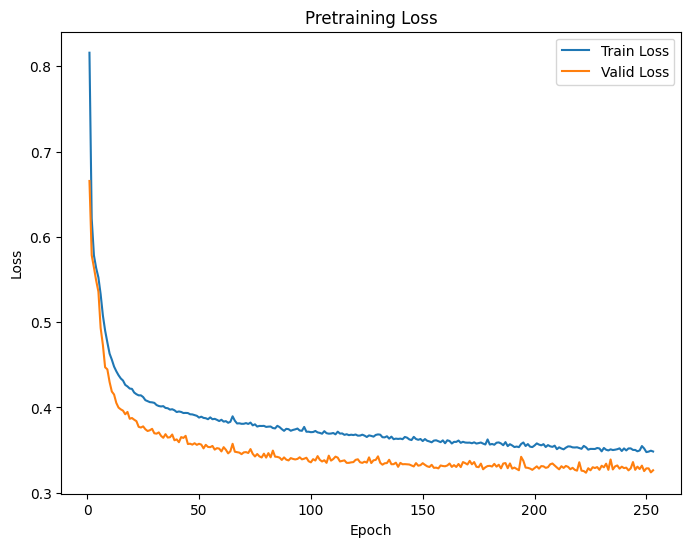

In [10]:
optimizer_pretrain = torch.optim.AdamW(model.parameters(), lr=1e-3)
# Training the model
pretrain_model(model, train_loader, valid_loader, epochs=1000, optimizer=optimizer_pretrain, device=device, model_save_path='best_pretrained_dmask_model_relutime.pt', patience=30)

In [11]:
# try:
df_pretrain_results = validate_model(model, valid_loader, device=device)
# except:
#     print('Something went wrong with the validating function.')

In [12]:
df_pretrain_results = df_pretrain_results.loc[df_pretrain_results['Variable']!=38, :]

[Downstream] Epoch [1/1000] - Training:   0%|          | 0/189 [00:00<?, ?it/s]

[Downstream] Epoch [1/1000] - Validation:   0%|          | 0/48 [00:00<?, ?it/s]

[Epoch 1] Train Loss=0.3933, Valid Loss=0.3588, Valid AUROC=0.7805, AUPRC=0.4553


[Downstream] Epoch [2/1000] - Training:   0%|          | 0/189 [00:00<?, ?it/s]

[Downstream] Epoch [2/1000] - Validation:   0%|          | 0/48 [00:00<?, ?it/s]

...

[Downstream] Epoch [65/1000] - Validation:   0%|          | 0/48 [00:00<?, ?it/s]

[Epoch 65] Train Loss=0.2509, Valid Loss=0.3420, Valid AUROC=0.8203, AUPRC=0.5134


[Downstream] Epoch [66/1000] - Training:   0%|          | 0/189 [00:00<?, ?it/s]

[Downstream] Epoch [66/1000] - Validation:   0%|          | 0/48 [00:00<?, ?it/s]

[Epoch 66] Train Loss=0.2459, Valid Loss=0.3479, Valid AUROC=0.8241, AUPRC=0.5109
Early stopping triggered (downstream).


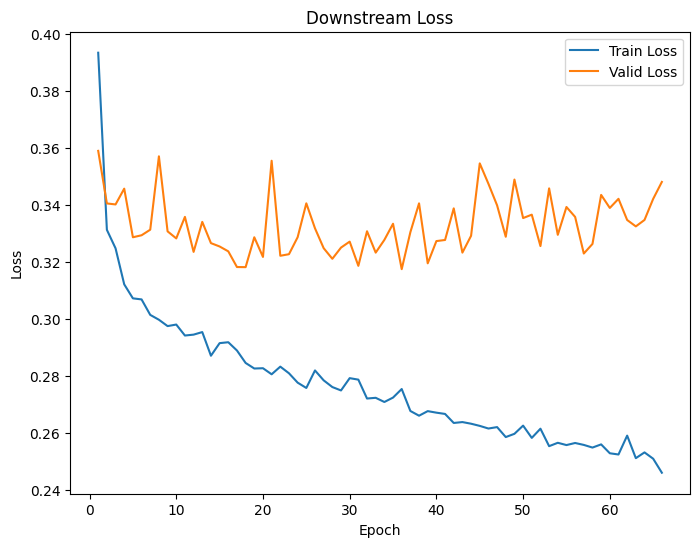

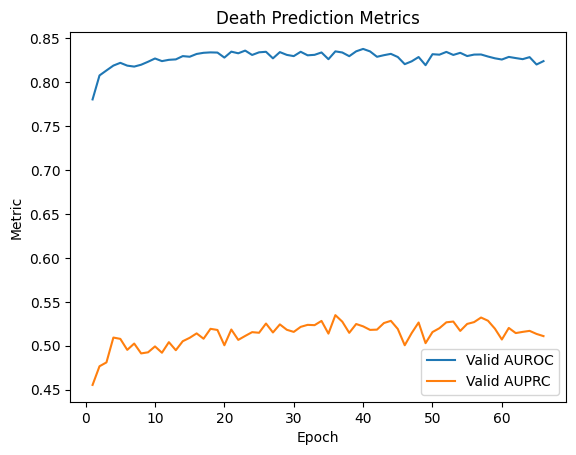

In [13]:

model = STraTSModel(num_features=num_features, embed_dim=embed_dim, num_heads=num_heads,
                    num_blocks=num_layers, ff_dim=ff_dim, dropout=dropout, activation=activation, final_emb_type=final_emb_type).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
model.load_state_dict(torch.load('best_pretrained_dmask_model_relutime.pt'))
df_downstream_loss = train_model(model, train_loader, valid_loader, epochs=1000, optimizer=optimizer, 
                                 device=device, model_save_path='best_downstream_dmask_model_relutime.pt', patience=30)

In [14]:
model = STraTSModel(num_features=num_features, embed_dim=embed_dim, num_heads=num_heads,
                    num_blocks=num_layers, ff_dim=ff_dim, dropout=dropout, activation=activation, final_emb_type=final_emb_type).to(device)
model.load_state_dict(torch.load('best_downstream_dmask_model_relutime.pt'))
metrics = evaluate_model(model, test_loader, device)
print("Test Metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

Test Metrics:
AUROC: 0.8542
AUPRC: 0.5194
Precision: 0.6022
Recall: 0.3173
F1: 0.4156
Accuracy: 0.8757


[Downstream] Epoch [1/1000] - Training:   0%|          | 0/189 [00:00<?, ?it/s]

[Downstream] Epoch [1/1000] - Validation:   0%|          | 0/48 [00:00<?, ?it/s]

[Epoch 1] Train Loss=0.5856, Valid Loss=0.5865, Valid AUROC=0.4829, AUPRC=0.1479


[Downstream] Epoch [2/1000] - Training:   0%|          | 0/189 [00:00<?, ?it/s]

[Downstream] Epoch [2/1000] - Validation:   0%|          | 0/48 [00:00<?, ?it/s]

...

[Downstream] Epoch [7/1000] - Validation:   0%|          | 0/48 [00:00<?, ?it/s]

[Epoch 7] Train Loss=0.5848, Valid Loss=0.5865, Valid AUROC=0.4829, AUPRC=0.1479


[Downstream] Epoch [8/1000] - Training:   0%|          | 0/189 [00:00<?, ?it/s]

[Downstream] Epoch [8/1000] - Validation:   0%|          | 0/48 [00:00<?, ?it/s]

[Epoch 8] Train Loss=0.5853, Valid Loss=0.5865, Valid AUROC=0.4829, AUPRC=0.1479
Early stopping triggered (downstream).


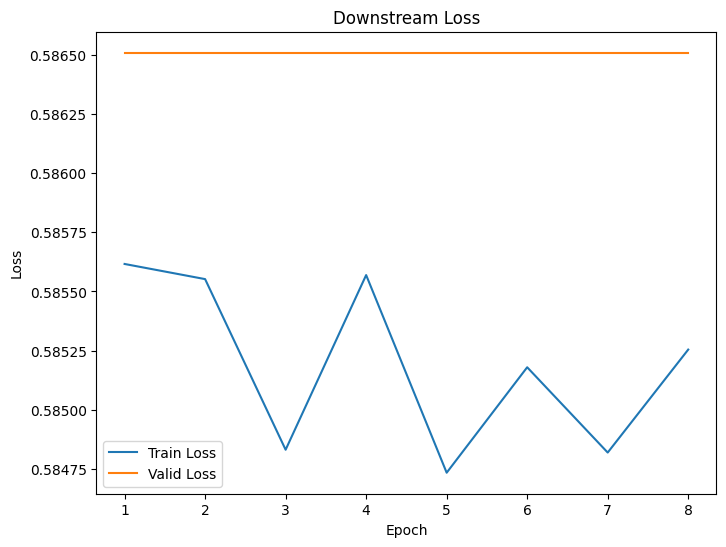

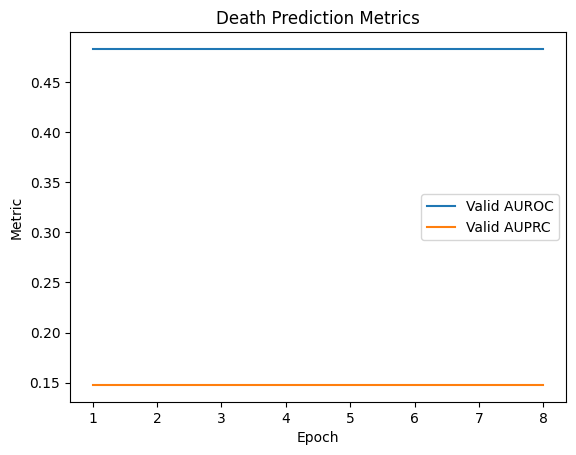

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
model = STraTSModel(num_features=num_features, embed_dim=embed_dim, num_heads=num_heads,
                    num_blocks=num_layers, ff_dim=ff_dim, dropout=dropout, activation=activation, final_emb_type=final_emb_type).to(device)

model.load_state_dict(torch.load("best_downstream_dmask_model_relutime.pt"))

df_downstream_loss_frozen = train_model(model, train_loader, valid_loader, epochs=1000, optimizer=optimizer, 
                                 device=device, freeze=True, model_save_path='best_frozen_downstream_dmask_model_relu.pt')

In [21]:
model.load_state_dict(torch.load('best_frozen_downstream_dmask_model_relutime.pt'))
metrics = evaluate_model(model, test_loader, device)
print("Test Metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

Test Metrics:
AUROC: 0.5145
AUPRC: 0.1524
Precision: 0.1667
Recall: 0.0212
F1: 0.0375
Accuracy: 0.8489


In [24]:
try:
    df_downstream_results = validate_model_downstream(model, valid_loader, device=device)
except:
    print('Something went wrong with the validating function.')


Something went wrong with the validating function.


In [18]:
for param in model.time_embed.parameters():
    print(param)


Parameter containing:
tensor([[-0.8461],
        [-0.7386],
        [ 0.2453],
        [ 2.0058],
        [-0.6507]], device='cuda:0')
Parameter containing:
tensor([ 0.8410,  0.7301,  0.1250,  0.4305, -0.5336], device='cuda:0')
Parameter containing:
tensor([[ 0.7205,  0.3873, -0.1651, -0.2055,  0.0682],
        [-0.2509, -0.1158, -0.1177,  0.0542,  0.2864],
        [ 0.7869,  0.3534, -0.0643, -0.1458,  0.0538],
        [-0.1287,  0.0982,  0.3090, -0.1602, -0.0563],
        [-0.0869,  0.4464,  0.0424,  0.0708, -0.2664],
        [-1.0064, -0.8125,  0.4590,  0.7237,  0.1696],
        [-0.2010,  0.2730, -0.2253,  0.1058,  0.1724],
        [-0.0223,  0.1758,  0.2497,  0.2147,  0.1733],
        [-0.6600, -0.5592,  0.1096,  0.5701,  0.1090],
        [ 0.7344,  0.3704, -0.3758, -0.7748,  0.0852],
        [ 1.3690,  0.9543,  0.1767, -0.5114,  0.1959],
        [ 0.2773, -0.2159, -0.1346, -0.0202,  0.2205],
        [-0.5784,  0.3493,  0.2308,  0.3852, -0.2209],
        [-0.6635, -0.1337,  0.0211,

In [19]:
for param in model.value_embed.parameters():
    print(param)


Parameter containing:
tensor([[-0.6417],
        [ 0.3248],
        [ 0.0587],
        [-0.5989],
        [-0.6133]], device='cuda:0')
Parameter containing:
tensor([-0.7530, -0.6913,  0.5080,  0.1191, -0.4668], device='cuda:0')
Parameter containing:
tensor([[-0.0272, -0.1997, -0.2279, -0.3041,  0.1769],
        [-0.3982,  0.5917,  0.0736, -0.5171, -0.3106],
        [-0.4252, -0.3142, -0.3136,  0.2518, -0.2279],
        [-0.3946, -0.8592, -0.4021,  0.3693, -0.1057],
        [ 0.3025, -0.0183, -0.0832, -0.4719,  0.1041],
        [-0.1412, -0.1106, -0.3157,  0.0147, -0.0044],
        [ 0.2821, -1.0254, -0.0667,  0.9018,  0.1401],
        [ 0.3032, -0.0472, -0.3074,  0.4176,  0.4614],
        [-0.0719, -0.0538, -0.5188,  0.1336, -0.1966],
        [ 0.0733, -0.0873, -0.0918, -0.2083,  0.0961],
        [ 0.0552, -0.0537,  0.0126, -0.0381, -0.0786],
        [-0.0211, -0.3312,  0.0451, -0.6710, -0.7156],
        [-0.2269,  0.1234,  0.0453,  0.0583, -0.0893],
        [ 0.0399, -0.5973, -0.4333,

In [20]:
version = '1task426432tmask'
df_downstream_loss.to_csv(f'downstream_loss_{version}.csv')
df_downstream_loss_frozen.to_csv(f'downstream_loss_frozen_{version}.csv')
df_pretrain_results.to_csv(f'pretrain_results_{version}.csv')